In [4]:
import pandas as pd
import plotly.graph_objects as go

# Load dataset
df = pd.read_csv("co2_emissions.csv")

# Check columns
print(df.head())

         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


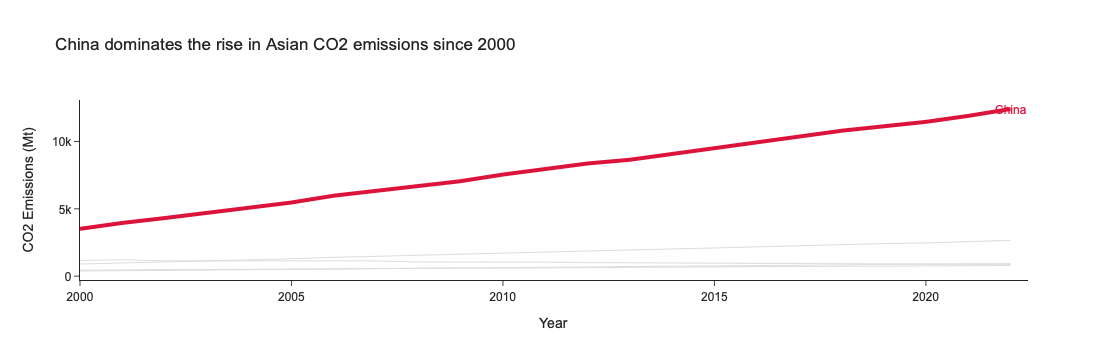

In [6]:
# Task 1 — Multi-series line with highlight

asia = df[df['Region'] == 'Asia']
highlight_country = 'China'

fig = go.Figure()

for country in asia['Country'].unique():
    country_df = asia[asia['Country'] == country]

    if country == highlight_country:
        fig.add_trace(go.Scatter(
            x=country_df['Year'],
            y=country_df['CO2_Mt'],
            mode='lines',
            line=dict(color='crimson', width=4),
            name=country
        ))

        fig.add_annotation(
            x=country_df['Year'].max(),
            y=country_df['CO2_Mt'].iloc[-1],
            text=country,
            showarrow=False,
            font=dict(color='crimson', size=12)
        )
    else:
        fig.add_trace(go.Scatter(
            x=country_df['Year'],
            y=country_df['CO2_Mt'],
            mode='lines',
            line=dict(color='#DDDDDD', width=1),
            hoverinfo='skip',
            showlegend=False
        ))

fig.update_layout(
    title='China dominates the rise in Asian CO2 emissions since 2000',
    template='simple_white',
    font=dict(family='Arial'),
    xaxis_title='Year',
    yaxis_title='CO2 Emissions (Mt)',
    showlegend=False
)

fig.show()

In [ ]:
#Insight
#China shows a dramatic increase in CO2 emissions over time compared to other Asian countries, indicating its dominant contribution to regional emissions growt

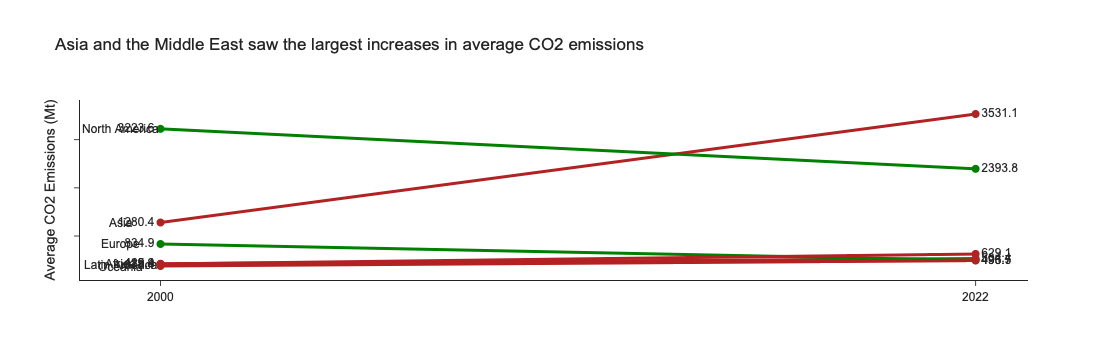

In [7]:
# Task 2 — Slopegraph: regional averages

regional = (
    df.groupby(['Region', 'Year'])['CO2_Mt']
    .mean()
    .reset_index()
)

regional = regional[regional['Year'].isin([2000, 2022])]

pivot = regional.pivot(index='Region', columns='Year', values='CO2_Mt').reset_index()

fig = go.Figure()

for _, row in pivot.iterrows():
    color = 'green' if row[2022] < row[2000] else 'firebrick'

    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[row[2000], row[2022]],
        mode='lines+markers+text',
        line=dict(color=color, width=3),
        marker=dict(size=8),
        text=[f"{row[2000]:.1f}", f"{row[2022]:.1f}"],
        textposition=['middle left', 'middle right'],
        showlegend=False
    ))

    fig.add_annotation(
        x=2000,
        y=row[2000],
        text=row['Region'],
        showarrow=False,
        xshift=-40
    )

fig.update_layout(
    title='Asia and the Middle East saw the largest increases in average CO2 emissions',
    template='simple_white',
    font=dict(family='Arial'),
    xaxis=dict(
        tickvals=[2000, 2022]
    ),
    yaxis=dict(
        title='Average CO2 Emissions (Mt)',
        showticklabels=False
    )
)

fig.show()

In [ ]:
#Insight
#Asia and the Middle East experienced the largest increases in average CO2 emissions between 2000 and 2022, while some regions showed slower growth or stabilization.